In [1]:
from torchvision.datasets import FashionMNIST

In [2]:
!ls

262_10315_174-pycharm-support-libs  best-cnn-model.keras  dataSet
Untitled.ipynb			    best_cnn_model.pt


In [3]:
fm_train = FashionMNIST(root='./dataSet/',train=True , download=True)
fm_test = FashionMNIST(root='./dataSet/',train=False ,download=True)

In [4]:
train_input = fm_train.data
train_target = fm_train.targets
train_scaled = train_input.reshape(-1, 1, 28, 28) / 255.0

In [5]:
train_scaled.shape

torch.Size([60000, 1, 28, 28])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scaled, train_target, test_size=0.2, random_state=42)

In [8]:
import torch.nn as nn
import torch

In [9]:
model = nn.Sequential()

In [10]:
model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

In [11]:
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))
model.add_module('flatten', nn.Flatten())

In [12]:
outputs = model(torch.ones(1, 1, 28 ,28))
print(outputs.shape)

torch.Size([1, 3136])


In [13]:
model.add_module('dense1', nn.Linear(3136, 100))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(0.3))
model.add_module('dens2', nn.Linear(100, 10))

In [14]:
import torch

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Sequential(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense1): Linear(in_features=3136, out_features=100, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (dens2): Linear(in_features=100, out_features=10, bias=True)
)

In [16]:
import torch.optim as optim

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [18]:
train_scaled.shape

torch.Size([48000, 1, 28, 28])

In [19]:
train_target.shape

torch.Size([48000])

In [20]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [22]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss / len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크 : {epoch+1}, 훈련 손실: {train_loss:.4f}, 검증 손실: {val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_cnn_model.pt')

    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f'{epoch +1}번째 에포크에서 조기 종료되었습니다.')
            break

에포크 : 1, 훈련 손실: 0.5661, 검증 손실: 0.3617
에포크 : 2, 훈련 손실: 0.3679, 검증 손실: 0.3090
에포크 : 3, 훈련 손실: 0.3182, 검증 손실: 0.3124
에포크 : 4, 훈련 손실: 0.2876, 검증 손실: 0.2622
에포크 : 5, 훈련 손실: 0.2604, 검증 손실: 0.2363
에포크 : 6, 훈련 손실: 0.2401, 검증 손실: 0.2315
에포크 : 7, 훈련 손실: 0.2242, 검증 손실: 0.2269
에포크 : 8, 훈련 손실: 0.2064, 검증 손실: 0.2275
에포크 : 9, 훈련 손실: 0.1909, 검증 손실: 0.2235
에포크 : 10, 훈련 손실: 0.1778, 검증 손실: 0.2329
에포크 : 11, 훈련 손실: 0.1669, 검증 손실: 0.2319
11번째 에포크에서 조기 종료되었습니다.


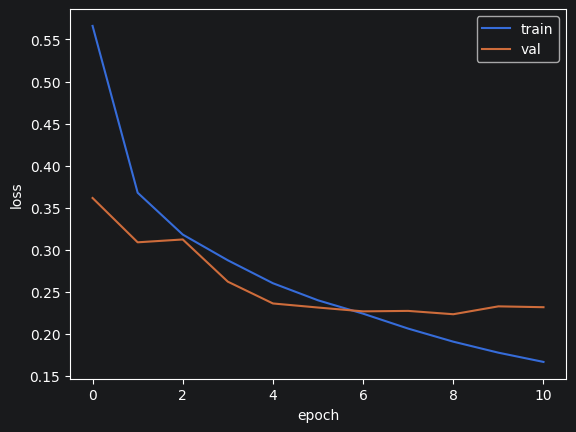

In [23]:
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [25]:
model.load_state_dict(torch.load('best_cnn_model.pt', weights_only=True))

<All keys matched successfully>

In [26]:
model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9221


In [29]:
test_scaled = fm_test.data.reshape(-1, 1, 28, 28) / 255.0
test_target = fm_test.targets

test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [31]:
model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"검증 정확도: {accuracy:.4f}")

검증 정확도: 0.9144
